# Comparative Analysis of Book Adaptations on Amazon Prime Video and Netflix

## Project Overview

Book-to-screen adaptations have become an important component of streaming platform content strategies. Services such as Amazon Prime Video and Netflix increasingly rely on literary works to create movies and series that attract diverse audiences. However, the success of an adaptation depends on multiple factors, including the quality of the source material, genre, adaptation format, and audience reception.

This project aims to compare book adaptations available on Amazon Prime Video and Netflix by integrating data from multiple sources, including Wikipedia, IMDb, and Goodreads. The analysis explores differences in adaptation quality, genre preferences, audience reception, and popularity across platforms.

The dataset consists of **249 book adaptations** released between **2015 and 2026**, containing information on IMDb ratings, Goodreads ratings, genres, votes, adaptation format (movie/series), and platform.

## Objectives

The primary objectives of this analysis are:

1. Compare adaptation quality across Amazon Prime Video and Netflix.
2. Examine the relationship between Goodreads ratings and IMDb ratings.
3. Analyze genre preferences and their impact on audience reception.
4. Compare the performance of movie and series adaptations.
5. Investigate trends in adaptation quality over time.
6. Explore the relationship between popularity and audience ratings.

## Dataset Description

The final dataset contains the following attributes:

* **Title** – Name of the adaptation
* **Premiere** – Release date
* **Rated** – Content rating (e.g., TV-MA, PG-13)
* **IMDb Rating** – Audience rating on IMDb (out of 10)
* **IMDb Votes** – Number of audience votes on IMDb
* **IMDb Genre** – Genres associated with the adaptation
* **IMDb Year** – Release year
* **IMDb Type** – Adaptation format (movie or series)
* **Platform** – Streaming platform (Amazon or Netflix)
* **Book Title** – Title of the source book
* **Book Author** – Author of the source book
* **Goodreads Rating** – Average Goodreads rating of the source book


**Note:** The dataset contains more Netflix adaptations (187 titles) than Amazon adaptations (62 titles). This imbalance arises because Netflix adaptation data was collected by web scraping multiple Wikipedia pages spanning 2015–2026, whereas Amazon adaptation data was obtained from a single Wikipedia source. The web scraping and data collection processes were performed in separate notebooks. Therefore, comparisons between platforms should be interpreted with caution, as the dataset does not represent the complete catalogs of either platform.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/final/book_adaptations.csv')

In [2]:
df.head()

,Title,Premiere,Rated,imdb_rating,imdb_votes,imdb_genre,imdb_year,imdb_type,platform,book_title,book_author,goodreads_rating
0,Reacher,04/02/2022,TV-MA,8.0,291841,"Action, Crime, Drama",2022,series,Amazon,jack reacher,lee child,4.08
1,The Summer I Turned Pretty,17/06/2022,TV-14,7.2,74872,"Drama, Romance",2022,series,Amazon,the summer i turned pretty,jenny han,3.73
2,The Terminal List,01/07/2022,TV-MA,7.9,127044,"Action, Drama, Thriller",2022,series,Amazon,the terminal list,jack carr,4.29
3,The Lord of the Rings: The Rings of Power,01/09/2022,TV-14,6.9,436113,"Action, Adventure, Drama",2022,series,Amazon,the lord of the rings and related middle-earth...,j. r. r. tolkien,4.50
4,Cross,14/11/2024,TV-MA,7.2,34967,"Action, Crime, Drama",2024,series,Amazon,alex cross,james patterson,4.13


In [3]:
df.shape

(249, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             249 non-null    str    
 1   Premiere          249 non-null    str    
 2   Rated             236 non-null    str    
 3   imdb_rating       249 non-null    float64
 4   imdb_votes        249 non-null    int64  
 5   imdb_genre        249 non-null    str    
 6   imdb_year         249 non-null    int64  
 7   imdb_type         249 non-null    str    
 8   platform          249 non-null    str    
 9   book_title        249 non-null    str    
 10  book_author       249 non-null    str    
 11  goodreads_rating  249 non-null    float64
dtypes: float64(2), int64(2), str(8)
memory usage: 23.5 KB


In [5]:
df.describe()

,imdb_rating,imdb_votes,imdb_year,goodreads_rating
count,249.000000,249.000000,249.000000,249.000000
mean,6.409237,51382.132530,2022.156627,3.920120
std,0.931286,84511.904344,2.418754,0.296973
min,2.700000,42.000000,2015.000000,2.840000
25%,5.900000,6572.000000,2020.000000,3.730000
50%,6.500000,20986.000000,2022.000000,3.940000
75%,7.000000,58387.000000,2024.000000,4.120000
max,8.700000,618310.000000,2026.000000,4.590000


In [6]:
df.isnull().sum()

Title                0
Premiere             0
Rated               13
imdb_rating          0
imdb_votes           0
imdb_genre           0
imdb_year            0
imdb_type            0
platform             0
book_title           0
book_author          0
goodreads_rating     0
dtype: int64

In [7]:
df['platform'].value_counts()

platform
Netflix    187
Amazon      62
Name: count, dtype: int64

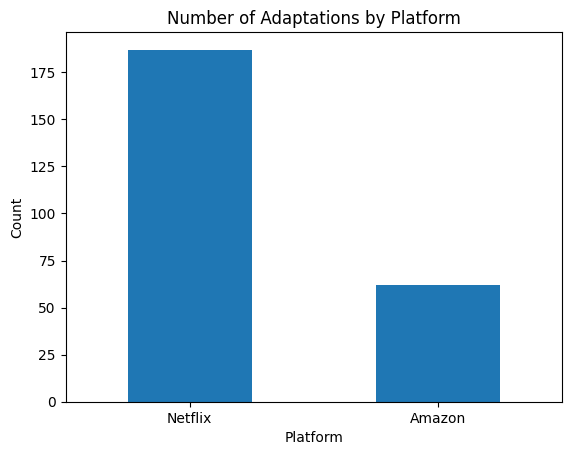

In [8]:
df['platform'].value_counts().plot(kind='bar')

plt.title('Number of Adaptations by Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

**Insight 1**

Within the collected dataset, Netflix adaptations substantially outnumber Amazon adaptations. However, this difference primarily reflects the availability of source data rather than the actual number of adaptations produced by each platform.

In [9]:
df.groupby('platform')['imdb_rating'].mean()

platform
Amazon     6.506452
Netflix    6.377005
Name: imdb_rating, dtype: float64

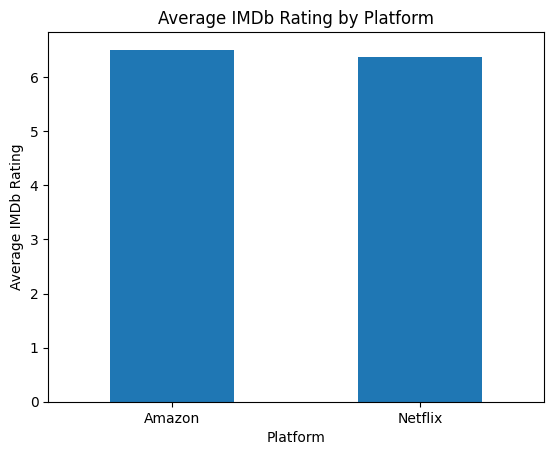

In [10]:
avg_ratings = df.groupby('platform')['imdb_rating'].mean()

avg_ratings.plot(kind='bar')

plt.title('Average IMDb Rating by Platform')
plt.xlabel('Platform')
plt.ylabel('Average IMDb Rating')
plt.xticks(rotation=0)

plt.show()

**Insight 2**

Amazon adaptations have a slightly higher average IMDb rating (6.50) compared to Netflix adaptations (6.38). However, the difference between the two platforms is relatively small, suggesting that adaptation quality, as measured by IMDb ratings, is broadly comparable across both platforms.

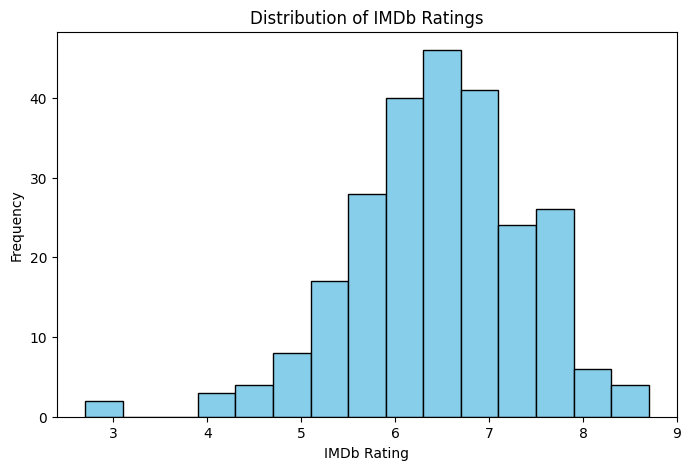

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['imdb_rating'], bins=15, edgecolor='black', color='skyblue')

plt.title('Distribution of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Frequency')

plt.savefig('../visuals/imdb_rating_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

**Observations:**
- Most adaptations are concentrated in the 6–7 IMDb rating range.
- The distribution appears to be roughly bell-shaped (approximately normal).
- There are very few poorly rated adaptations (below 5).
- There are also only a few highly rated adaptations (above 8).
- Overall, the majority of adaptations receive moderate ratings rather than extremely high or low ratings.

**Insight 3**

Most book adaptations in the dataset receive moderate IMDb ratings, with the majority of titles clustered between ratings of 6 and 7. Extremely low-rated and highly rated adaptations are relatively rare.

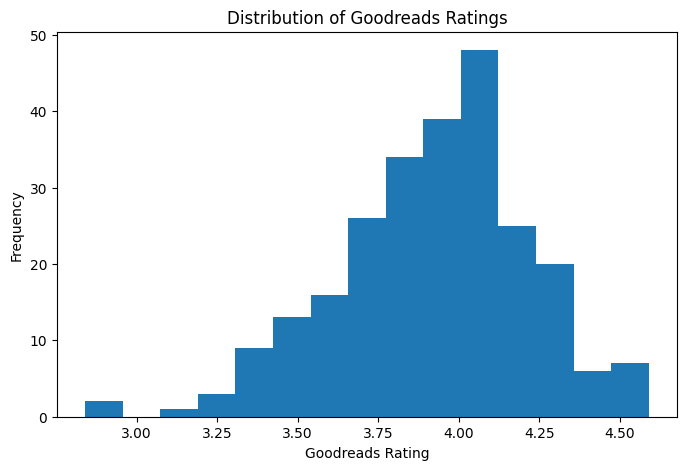

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['goodreads_rating'], bins=15)

plt.title('Distribution of Goodreads Ratings')
plt.xlabel('Goodreads Rating')
plt.ylabel('Frequency')

plt.show()

**Observations:**
- Most books have Goodreads ratings between 3.7 and 4.2.
- The distribution is concentrated around 4.0, indicating that the majority of source books are generally well-received by readers.
- There are very few books with ratings below 3.5, suggesting that low-rated books are rarely adapted.
- The distribution appears to be slightly left-skewed (negatively skewed) because ratings are clustered near the upper end of the 5-point scale.

**Insight 4**

Most adaptations in the dataset are based on highly rated books, with Goodreads ratings heavily concentrated around 4.0. This suggests that streaming platforms tend to adapt books that have already gained positive reception among readers.

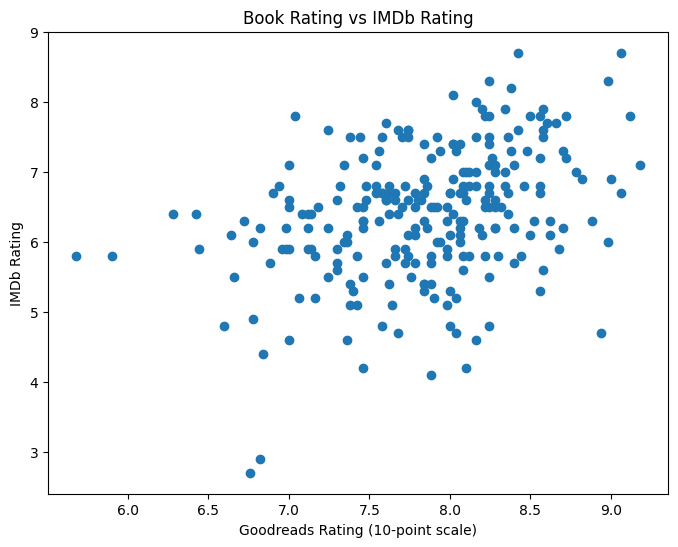

In [13]:
df['goodreads_rating_10'] = df['goodreads_rating'] * 2

plt.figure(figsize=(8,6))

plt.scatter(df['goodreads_rating_10'], df['imdb_rating'])

plt.xlabel('Goodreads Rating (10-point scale)')
plt.ylabel('IMDb Rating')
plt.title('Book Rating vs IMDb Rating')

plt.savefig('../visuals/goodreads_vs_imdb.png',dpi=300,bbox_inches='tight')
plt.show()

In [14]:
df[['goodreads_rating_10', 'imdb_rating']].corr()

,goodreads_rating_10,imdb_rating
goodreads_rating_10,1.00000,0.36596
imdb_rating,0.36596,1.00000


**Observations:**
- The correlation between Goodreads ratings and IMDb ratings is 0.36, indicating a moderate positive relationship.
- While highly rated books generally tend to receive better adaptation ratings, the relationship is not strong.
- Several highly rated books received only average IMDb ratings, suggesting that factors other than source material quality also influence adaptation success.

**Insight 5**

The correlation between Goodreads ratings and IMDb ratings is moderate (r = 0.36), indicating that while highly rated books tend to produce better adaptations, book quality alone does not guarantee adaptation success.

In [15]:
genre_df = df.copy()

genre_df['imdb_genre'] = genre_df['imdb_genre'].str.split(', ')

genre_df = genre_df.explode('imdb_genre')

In [16]:
genre_df.head(10)

,Title,Premiere,Rated,imdb_rating,imdb_votes,imdb_genre,imdb_year,imdb_type,platform,book_title,book_author,goodreads_rating,goodreads_rating_10
0,Reacher,04/02/2022,TV-MA,8.0,291841,Action,2022,series,Amazon,jack reacher,lee child,4.08,8.16
0,Reacher,04/02/2022,TV-MA,8.0,291841,Crime,2022,series,Amazon,jack reacher,lee child,4.08,8.16
0,Reacher,04/02/2022,TV-MA,8.0,291841,Drama,2022,series,Amazon,jack reacher,lee child,4.08,8.16
1,The Summer I Turned Pretty,17/06/2022,TV-14,7.2,74872,Drama,2022,series,Amazon,the summer i turned pretty,jenny han,3.73,7.46
1,The Summer I Turned Pretty,17/06/2022,TV-14,7.2,74872,Romance,2022,series,Amazon,the summer i turned pretty,jenny han,3.73,7.46
2,The Terminal List,01/07/2022,TV-MA,7.9,127044,Action,2022,series,Amazon,the terminal list,jack carr,4.29,8.58
2,The Terminal List,01/07/2022,TV-MA,7.9,127044,Drama,2022,series,Amazon,the terminal list,jack carr,4.29,8.58
2,The Terminal List,01/07/2022,TV-MA,7.9,127044,Thriller,2022,series,Amazon,the terminal list,jack carr,4.29,8.58
3,The Lord of the Rings: The Rings of Power,01/09/2022,TV-14,6.9,436113,Action,2022,series,Amazon,the lord of the rings and related middle-earth...,j. r. r. tolkien,4.50,9.00
3,The Lord of the Rings: The Rings of Power,01/09/2022,TV-14,6.9,436113,Adventure,2022,series,Amazon,the lord of the rings and related middle-earth...,j. r. r. tolkien,4.50,9.00


In [17]:
genre_df['imdb_genre'].value_counts()

imdb_genre
Drama          176
Romance         70
Comedy          70
Crime           52
Action          47
Mystery         47
Thriller        41
Adventure       36
Biography       22
Horror          20
Animation       19
Fantasy         17
History         13
Sci-Fi           9
Documentary      7
Family           7
Short            5
Music            4
Sport            3
War              3
Western          2
Haunting         1
Name: count, dtype: int64

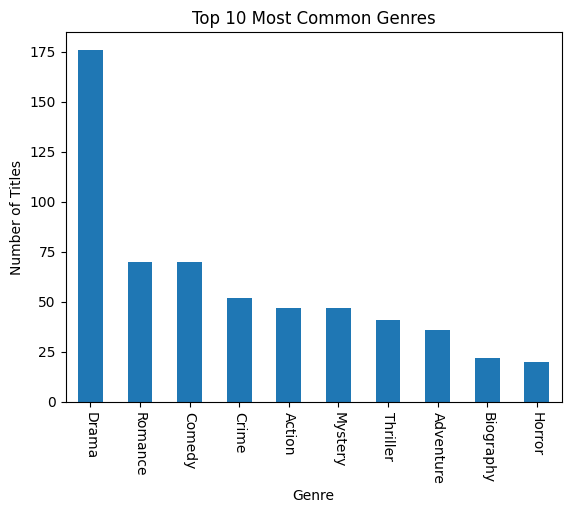

In [18]:
top_genres = genre_df['imdb_genre'].value_counts().head(10)

top_genres.plot(kind='bar')

plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=270)

plt.show()

**Observations:**

- Drama is by far the most common genre among book adaptations, appearing in 175 titles.
- Comedy and Romance are the second and third most frequent genres, with equal occurrences.
- Crime, Action, Mystery, and Thriller are also commonly represented.
- Genres such as Western, War, and Sport appear relatively infrequently in the dataset.

**Insight 6**

Drama dominates the adaptation landscape, suggesting that streaming platforms frequently adapt character-driven and emotionally focused stories. Comedy and Romance adaptations are also highly prevalent, whereas genres such as Western and War are comparatively rare.

In [19]:
genre_stats = (
    genre_df.groupby('imdb_genre')
             .agg(avg_rating=('imdb_rating', 'mean'),
                  count=('imdb_rating', 'count'))
             .sort_values(by='avg_rating', ascending=False)
)

genre_stats

,avg_rating,count
imdb_genre,,
Haunting,7.700000,1
Sport,7.433333,3
War,7.400000,3
History,7.007692,13
Documentary,6.942857,7
Music,6.925000,4
Biography,6.922727,22
Short,6.880000,5
Western,6.800000,2


In [20]:
genre_stats_filtered = genre_stats[genre_stats['count'] >= 10]

genre_stats_filtered

,avg_rating,count
imdb_genre,,
History,7.007692,13
Biography,6.922727,22
Animation,6.652632,19
Adventure,6.616667,36
Action,6.553191,47
Drama,6.508523,176
Fantasy,6.505882,17
Crime,6.428846,52
Comedy,6.192857,70


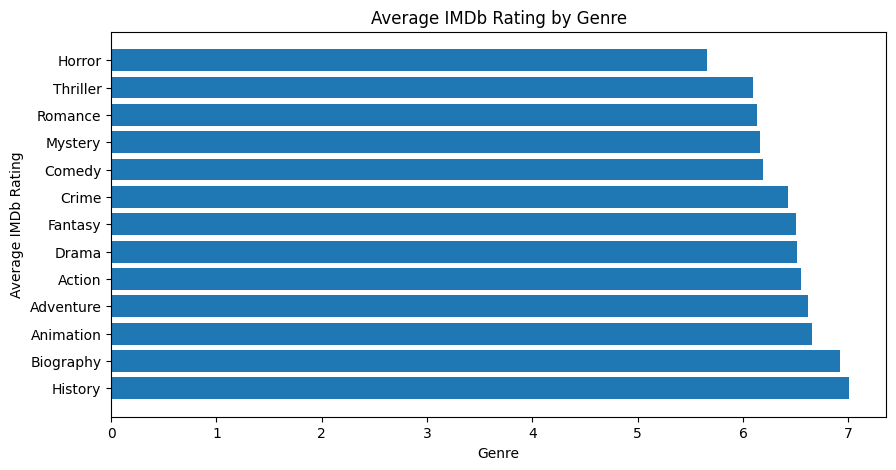

In [21]:
genre_stats_filtered = genre_stats_filtered.sort_values(
    by='avg_rating',
    ascending=False
)

plt.figure(figsize=(10,5))

plt.barh(
    genre_stats_filtered.index,
    genre_stats_filtered['avg_rating']
)

plt.title('Average IMDb Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Rating')
plt.xticks()

plt.savefig('../visuals/genre_ratings.png',dpi=300,bbox_inches='tight')
plt.show()

**Observations:**

- History and Biography adaptations receive the highest average IMDb ratings among frequently occurring genres.
- Horror adaptations have the lowest average IMDb ratings.
- Drama is the most common genre but does not have the highest average rating.
- Genres such as Animation, Adventure, and Action generally perform above the overall average.

**Insight 7**

Historical and biographical adaptations tend to receive the highest IMDb ratings, whereas Horror adaptations generally receive lower ratings. This suggests that audiences may respond more positively to fact-based or historically inspired stories than to horror adaptations.

In [22]:
genre_combinations = df['imdb_genre'].value_counts()

genre_combinations.head(10)

imdb_genre
Drama, Romance                  25
Crime, Drama, Mystery           17
Comedy, Drama, Romance          17
Animation, Adventure, Comedy     8
Comedy, Romance                  7
Action, Adventure, Drama         6
Animation, Action, Adventure     6
Crime, Drama, Thriller           6
Drama                            6
Comedy, Drama                    6
Name: count, dtype: int64

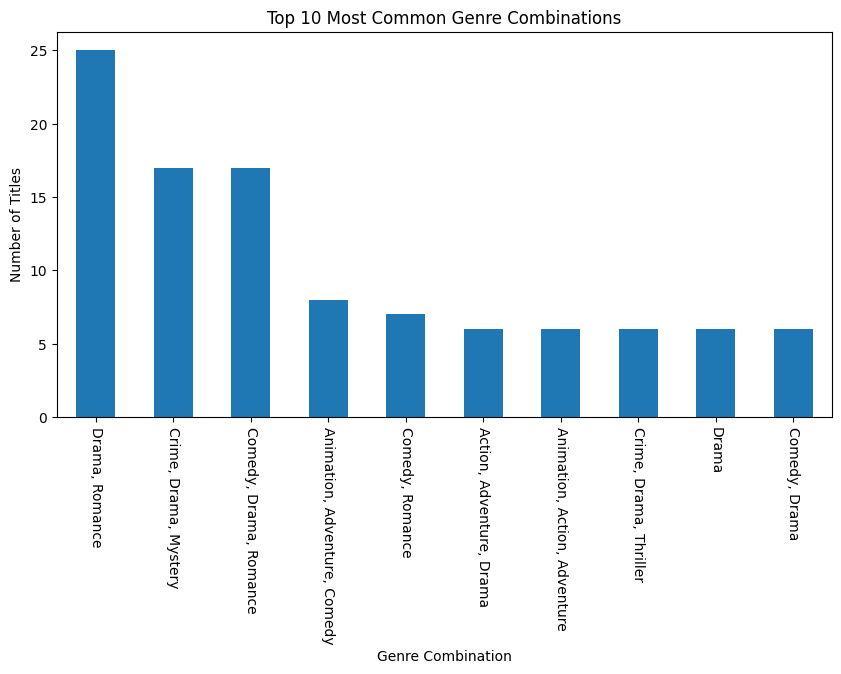

In [23]:
top_combinations = df['imdb_genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_combinations.plot(kind='bar')

plt.title('Top 10 Most Common Genre Combinations')
plt.xlabel('Genre Combination')
plt.ylabel('Number of Titles')
plt.xticks(rotation=270)

plt.show()

**Observations:**

- Drama, Romance is the most common genre combination, appearing in 25 titles.
- Crime, Drama, Mystery and Comedy, Drama, Romance are also highly prevalent, with 17 titles each.
- Drama appears in almost all of the top combinations, reinforcing its dominance in the adaptation landscape.
- Combinations involving Romance, Crime, Mystery, and Comedy are particularly common among adaptations.

**Insight 8**

Genre combinations involving Drama dominate the dataset, with Drama-Romance emerging as the most frequent combination. This suggests that streaming platforms often adapt stories that blend emotional narratives with romance, crime, or mystery elements.

In [24]:
combo_stats = (
    df.groupby('imdb_genre')
      .agg(avg_rating=('imdb_rating', 'mean'),
           count=('imdb_rating', 'count'))
      .sort_values(by='avg_rating', ascending=False)
)

combo_stats.head(20)

,avg_rating,count
imdb_genre,,
"Action, Adventure, Comedy, Drama, Fantasy",8.300000,1
"Drama, Fantasy, History",8.300000,1
"Drama, Romance, Sport",8.200000,1
"Biography, Drama, Music",7.800000,1
"Crime, Drama, Mystery, Thriller",7.800000,1
"Drama, History, War",7.800000,1
"Drama, History, Romance",7.800000,1
"Drama, War",7.700000,1
"Drama, Romance, Haunting",7.700000,1


In [25]:
combo_stats_filtered = combo_stats[combo_stats['count'] >= 3]

combo_stats_filtered

,avg_rating,count
imdb_genre,,
"Crime, Drama",7.250000,4
"Action, Drama, Thriller",7.160000,5
Drama,7.133333,6
Documentary,7.100000,3
"Animation, Action, Adventure",6.983333,6
"Biography, Drama, History",6.960000,5
"Comedy, Drama",6.850000,6
"Action, Adventure, Drama",6.816667,6
"Action, Crime, Drama",6.640000,5


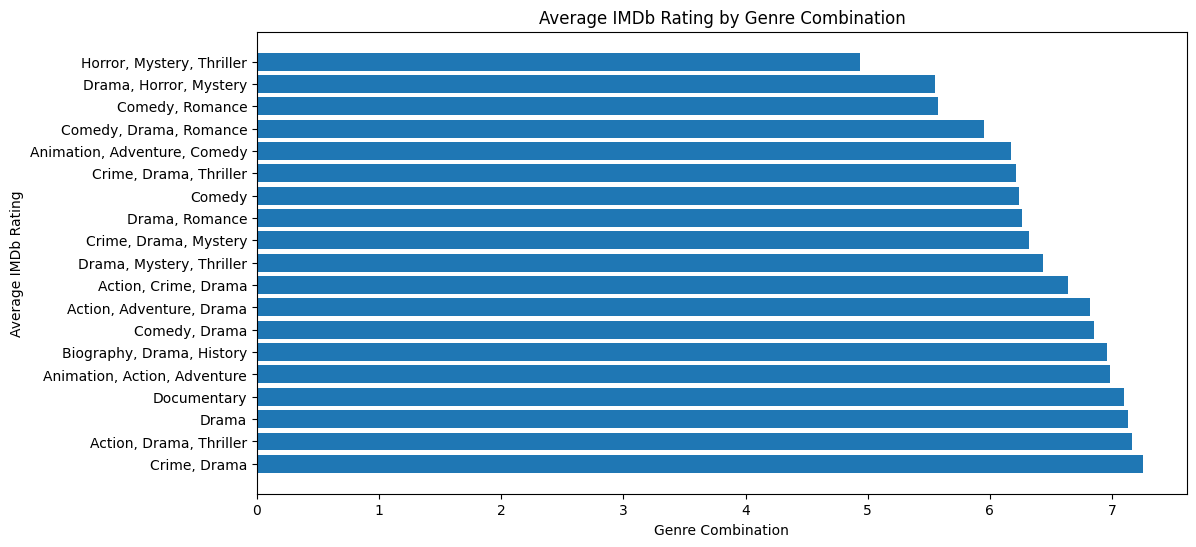

In [26]:
combo_stats_filtered = combo_stats_filtered.sort_values(
    by='avg_rating',
    ascending=False
)

plt.figure(figsize=(12,6))

plt.barh(
    combo_stats_filtered.index,
    combo_stats_filtered['avg_rating']
)

plt.title('Average IMDb Rating by Genre Combination')
plt.xlabel('Genre Combination')
plt.ylabel('Average IMDb Rating')
plt.xticks()

plt.show()

**Observations:**

- Among frequently occurring genre combinations, "Crime, Drama" has the highest average IMDb rating (7.25), followed by "Action, Drama, Thriller" (7.16).
- Standalone Drama adaptations also perform well, with an average IMDb rating of 7.13.
- Genre combinations involving Crime and Drama generally receive higher ratings than average.
- Comedy-driven combinations such as "Comedy, Drama, Romance" and "Comedy, Romance" tend to receive comparatively lower ratings.
- Horror-oriented combinations receive the lowest ratings, with "Horror, Mystery, Thriller" averaging only 4.93.

**Insight 9**

Genre combinations centered around Crime and Drama tend to receive the highest IMDb ratings, whereas combinations involving Horror and Romance generally perform less favorably. This suggests that audiences may respond more positively to suspenseful and dramatic adaptations than to horror-focused or romance-heavy adaptations.

In [27]:
df['imdb_type'].value_counts()

imdb_type
movie     195
series     54
Name: count, dtype: int64

**Note:** The dataset contains a larger number of movies than series. This imbalance is primarily a consequence of the data collection process and the availability of source data across different Wikipedia pages. Therefore, comparisons between movies and series should be interpreted with caution, as the dataset does not represent the complete catalogs of either adaptation type.

In [28]:
df.groupby('imdb_type')['imdb_rating'].mean()

imdb_type
movie     6.17641
series    7.25000
Name: imdb_rating, dtype: float64

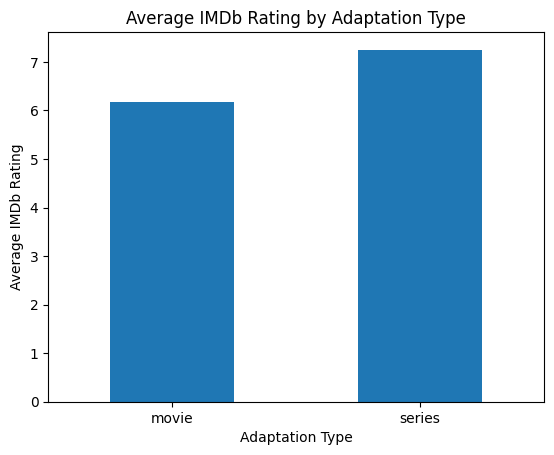

In [29]:
avg_type_ratings = df.groupby('imdb_type')['imdb_rating'].mean()

avg_type_ratings.plot(kind='bar')

plt.title('Average IMDb Rating by Adaptation Type')
plt.xlabel('Adaptation Type')
plt.ylabel('Average IMDb Rating')
plt.xticks(rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

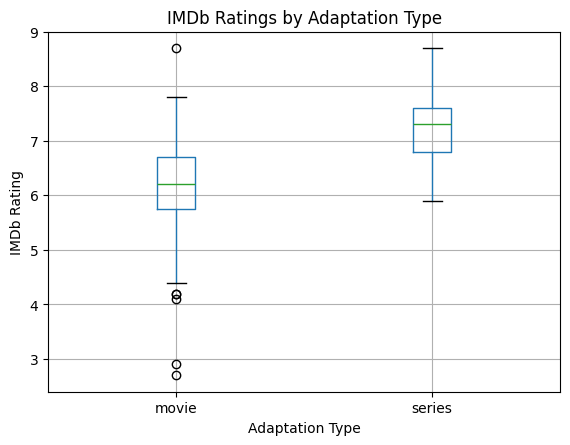

In [30]:
plt.figure(figsize=(8,5))

df.boxplot(column='imdb_rating', by='imdb_type')

plt.title('IMDb Ratings by Adaptation Type')
plt.suptitle('')  # removes extra default title
plt.xlabel('Adaptation Type')
plt.ylabel('IMDb Rating')

plt.savefig('../visuals/movies_vs_series.png',dpi=300,bbox_inches='tight')
plt.show()

**Observations:**

- Series adaptations consistently receive higher IMDb ratings than movie adaptations.
- The median IMDb rating for series is substantially higher than that of movies.
- Movie adaptations exhibit greater variability in ratings and include several low-rated outliers.
- Series adaptations show a narrower distribution, indicating more consistent audience reception.

**Insight 10**

Series adaptations tend to outperform movie adaptations in terms of IMDb ratings. The boxplot suggests that series not only receive higher ratings on average but also exhibit more consistent audience reception. A possible explanation is that the episodic format allows for richer storytelling and more faithful adaptation of source material.

In [31]:
yearly_ratings = (
    df.groupby('imdb_year')['imdb_rating']
      .mean()
)

yearly_ratings

imdb_year
2015    7.700000
2016    6.900000
2017    6.200000
2018    6.375000
2019    6.550000
2020    6.346667
2021    6.512000
2022    6.309091
2023    6.358333
2024    6.222222
2025    6.515000
2026    6.738462
Name: imdb_rating, dtype: float64

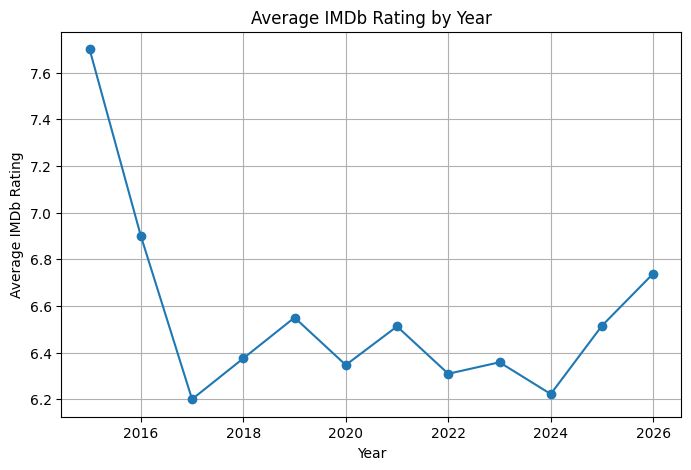

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_ratings.index,
    yearly_ratings.values,
    marker='o'
)

plt.title('Average IMDb Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average IMDb Rating')

plt.grid(True)

plt.show()

In [33]:
yearly_counts = df['imdb_year'].value_counts().sort_index()

yearly_counts

imdb_year
2015     1
2016     2
2017     9
2018     8
2019    14
2020    30
2021    25
2022    44
2023    36
2024    27
2025    40
2026    13
Name: count, dtype: int64

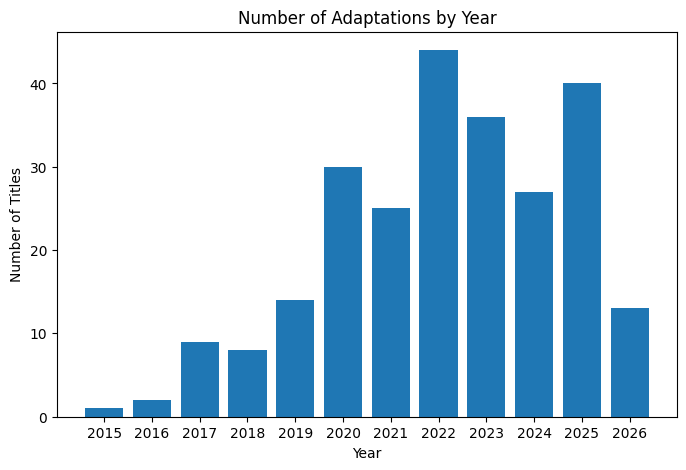

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_counts.index.astype(str),
    yearly_counts.values
)

plt.title('Number of Adaptations by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

**Observations:**

- The number of adaptations in the dataset increases considerably after 2020.
- Early years such as 2015 and 2016 contain very few titles, making their average ratings less reliable.
- From 2020 onwards, average IMDb ratings remain relatively stable, generally ranging between 6.2 and 6.5.
- No clear long-term upward or downward trend in adaptation ratings is observed over time.

**Insight 11**

Despite fluctuations across individual years, adaptation ratings remain relatively stable over time. The analysis does not reveal a strong long-term trend toward either improving or declining adaptation quality.

<Figure size 800x500 with 0 Axes>

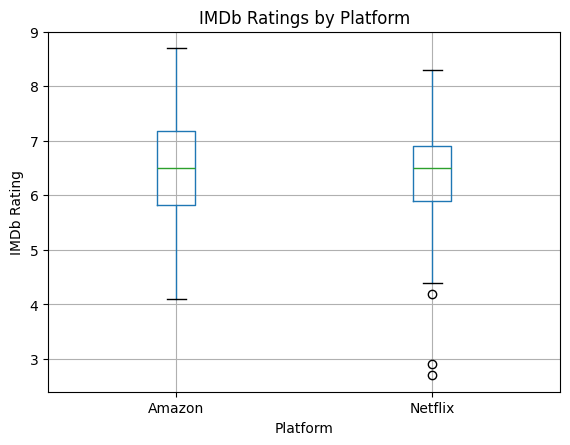

In [35]:
import matplotlib.pyplot as plt
import pandas as pd 

plt.figure(figsize=(8,5))

df.boxplot(column='imdb_rating', by='platform')

plt.title('IMDb Ratings by Platform')
plt.suptitle('')  # Removes the automatic title
plt.xlabel('Platform')
plt.ylabel('IMDb Rating')

plt.savefig('../visuals/platform_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

**Observations:**

- Amazon and Netflix adaptations exhibit very similar rating distributions.
- Both platforms have an identical median IMDb rating of 6.5.
- Netflix contains several low-rated outliers, which contribute to its slightly lower average rating.
- The middle 50% of ratings are comparable across both platforms, indicating similar audience reception overall.

**Insight 12**

Despite Amazon adaptations having a marginally higher average IMDb rating, the boxplot reveals that both platforms exhibit remarkably similar rating distributions. This suggests that adaptation quality is broadly comparable across Amazon and Netflix.

In [36]:
df.groupby('platform')['goodreads_rating'].mean()

platform
Amazon     3.935323
Netflix    3.915080
Name: goodreads_rating, dtype: float64

**Observations:**

- Amazon and Netflix adaptations are based on books with very similar Goodreads ratings.
- The average Goodreads rating for Amazon adaptations is 3.94, while Netflix adaptations average 3.92.
- The difference between the two platforms is minimal, indicating that both platforms tend to adapt similarly well-received books.

**Insight 13**

Amazon and Netflix appear to select source material of comparable quality, as evidenced by their nearly identical average Goodreads ratings. Therefore, differences in adaptation ratings are unlikely to be explained solely by the quality of the original books.

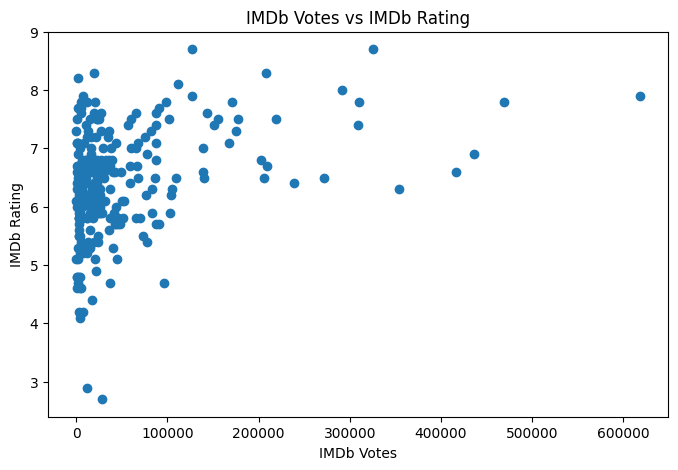

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(df['imdb_votes'],
            df['imdb_rating'])

plt.title('IMDb Votes vs IMDb Rating')
plt.xlabel('IMDb Votes')
plt.ylabel('IMDb Rating')

plt.show()

In [38]:
df[['imdb_votes', 'imdb_rating']].corr()

,imdb_votes,imdb_rating
imdb_votes,1.000000,0.340729
imdb_rating,0.340729,1.000000


Observation

- IMDb votes and IMDb ratings exhibit a moderate positive relationship (r = 0.340).
- Adaptations with a larger number of votes generally tend to receive higher ratings.
- Highly voted adaptations rarely receive extremely low ratings, with most maintaining ratings above 6.0.
- Adaptations with relatively few votes display greater variability, ranging from poorly rated titles to highly acclaimed ones.

**Insight 14**

Popularity and audience ratings exhibit a moderate positive relationship, suggesting that widely viewed adaptations tend to receive more favorable audience reception. However, popularity alone does not guarantee high ratings, as several less popular adaptations also achieve strong audience approval.

In [39]:
genre_df = genre_df.reset_index(drop=True)

platform_genres = pd.crosstab(
    genre_df['platform'],
    genre_df['imdb_genre']
)

platform_genres

imdb_genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Mystery,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
platform,,,,,,,,,,,,,,,,,,,,,
Amazon,14,7,2,5,11,11,5,42,1,3,...,4,1,8,23,4,0,2,10,0,0
Netflix,33,29,17,17,59,41,2,134,6,14,...,16,3,39,47,5,5,1,31,3,2


In [40]:
platform_genres_pct = pd.crosstab(
    genre_df['platform'],
    genre_df['imdb_genre'],
    normalize='index'
) * 100

platform_genres_pct.T.sort_values(
    by='Netflix',
    ascending=False
)

platform,Amazon,Netflix
imdb_genre,,
Drama,26.923077,26.019417
Comedy,7.051282,11.456311
Romance,14.743590,9.126214
Crime,7.051282,7.961165
Mystery,5.128205,7.572816
Action,8.974359,6.407767
Thriller,6.410256,6.019417
Adventure,4.487179,5.631068
Animation,1.282051,3.300971


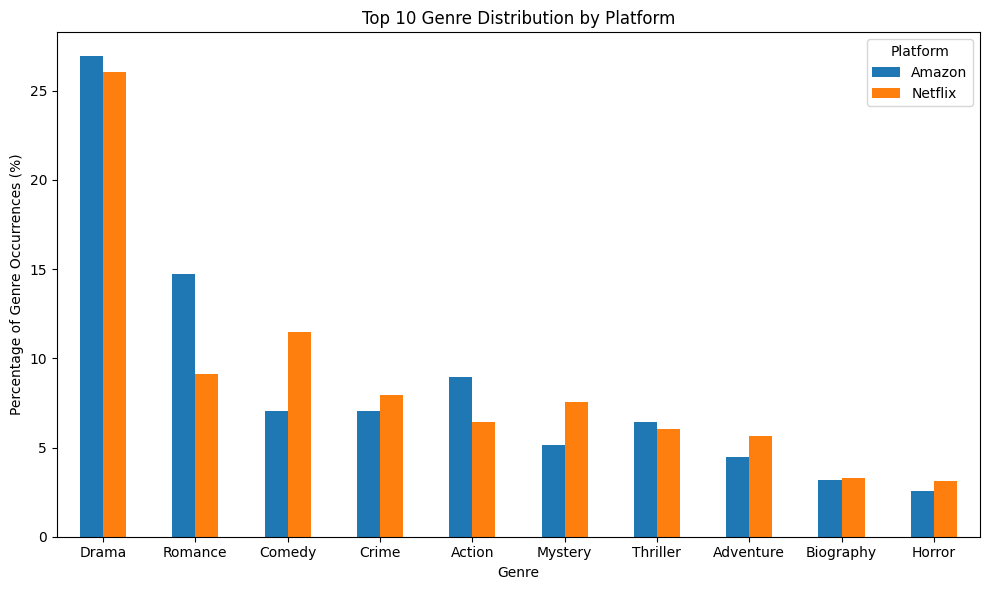

In [41]:
# Get top 10 genres overall
top_genres = genre_df['imdb_genre'].value_counts().head(10).index

# Filter dataframe
top_platform_genres = platform_genres_pct[top_genres]

# Plot
top_platform_genres.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Top 10 Genre Distribution by Platform')
plt.xlabel('Genre')
plt.ylabel('Percentage of Genre Occurrences (%)')
plt.xticks(rotation=0)
plt.legend(title='Platform')

plt.tight_layout()

plt.savefig('../visuals/platform_genre_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

- Drama dominates both platforms (~26% share on Amazon and Netflix).
- Netflix has a higher share of Comedy, Mystery, Adventure, Animation, and Fantasy compared to Amazon.
- Amazon shows stronger presence in Romance, Action, Sci-Fi, and Documentary.
- Crime, Thriller, and Biography are fairly similar across both platforms.
- Netflix includes War and Western, while Amazon does not.

**Insight 15**

Both Amazon and Netflix are strongly centered around Drama-driven content, showing nearly identical dominance in that genre. However, Amazon tends to lean more toward Romance, Action, Sci-Fi, and Documentary-based adaptations, while Netflix demonstrates a broader genre spread with stronger emphasis on Comedy, Mystery, Animation, and Fantasy, suggesting a more diversified adaptation strategy.

In [42]:
corr = df[['imdb_rating',
           'goodreads_rating',
           'imdb_votes',
           'imdb_year']].corr()

corr

,imdb_rating,goodreads_rating,imdb_votes,imdb_year
imdb_rating,1.000000,0.365960,0.340729,0.015645
goodreads_rating,0.365960,1.000000,0.171839,0.102365
imdb_votes,0.340729,0.171839,1.000000,-0.256345
imdb_year,0.015645,0.102365,-0.256345,1.000000


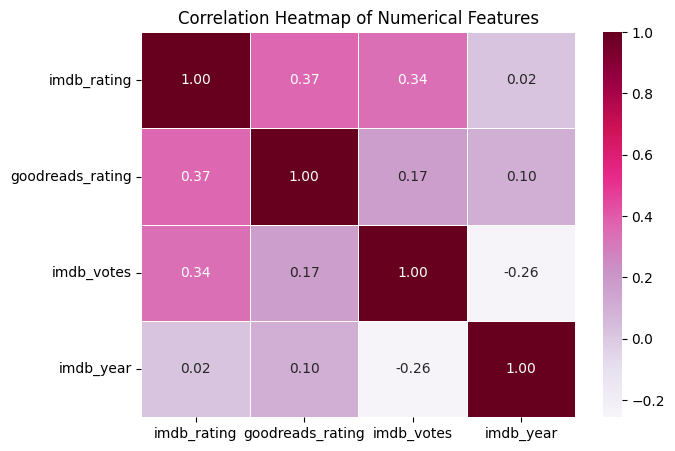

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
corr = df[['imdb_rating',
           'goodreads_rating',
           'imdb_votes',
           'imdb_year']].corr()

# Plot heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,      # Show correlation values
    cmap='PuRd', # Color palette
    fmt='.2f',       # Show 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')

plt.savefig('../visuals/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

- Goodreads ratings and IMDb ratings exhibit a moderate positive correlation (0.37), indicating that highly rated books tend to produce better adaptations.
- IMDb votes and IMDb ratings also show a moderate positive relationship (0.34), suggesting that popular adaptations generally receive favorable audience reception.
- IMDb year shows almost no correlation with IMDb ratings (0.02), implying that adaptation quality has remained relatively stable over time.
- The negative correlation between IMDb votes and release year (-0.26) suggests that older adaptations have had more time to accumulate votes.

In [44]:
top_rated = (
    df[['Title', 'platform','imdb_rating']]
    .sort_values(by='imdb_rating', ascending=False)
    .head(10)
)

top_rated

,Title,platform,imdb_rating
12,Invincible,Amazon,8.7
24,Soorarai Pottru,Amazon,8.7
77,One Piece,Netflix,8.3
91,One Hundred Years of Solitude,Netflix,8.3
11,Off Campus,Amazon,8.2
73,Dept. Q,Netflix,8.1
0,Reacher,Amazon,8.0
63,The Witcher,Netflix,7.9
2,The Terminal List,Amazon,7.9
87,Black Warrant,Netflix,7.9


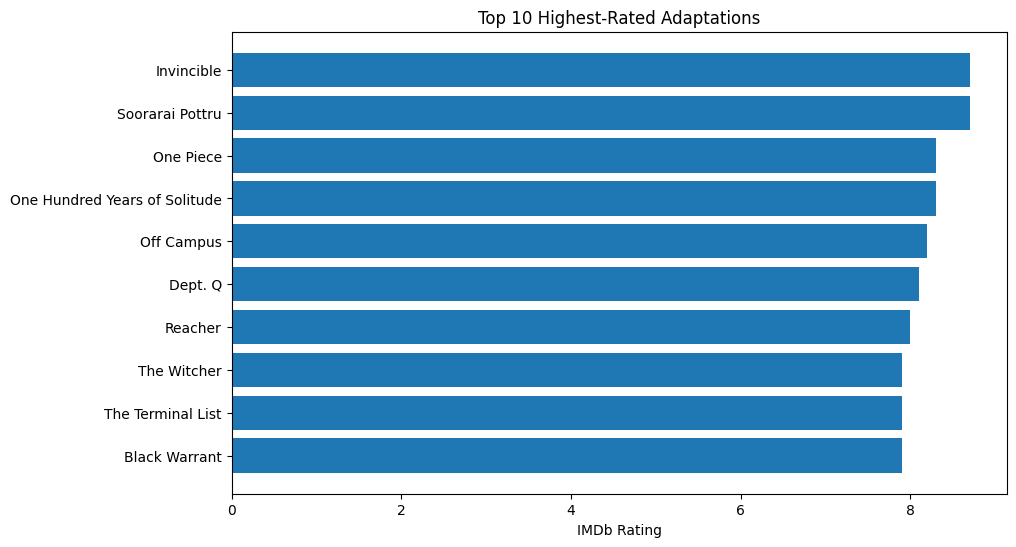

In [45]:
plt.figure(figsize=(10,6))

plt.barh(
    top_rated['Title'],
    top_rated['imdb_rating']
)

plt.title('Top 10 Highest-Rated Adaptations')
plt.xlabel('IMDb Rating')
plt.gca().invert_yaxis()

plt.savefig('../visuals/top_rated_adaptations.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

- The highest-rated adaptations in the dataset are "Soorarai Pottru" and "Invincible", both receiving an IMDb rating of 8.7.
- Both Amazon and Netflix are represented among the top-rated adaptations.
- Amazon contributes 5 of the top 10 highest-rated adaptations despite having a smaller dataset size.
- The top-rated adaptations span a variety of genres and formats, including animated series, literary classics, and action dramas.

**Insight 16**

Both platforms are capable of producing highly acclaimed adaptations. Notably, Amazon contributes several of the top-rated titles despite representing a smaller proportion of the overall dataset.

In [46]:
top_popular = (
    df[['Title', 'platform', 'imdb_votes']]
    .sort_values(by='imdb_votes', ascending=False)
    .head(10)
)

top_popular

,Title,platform,imdb_votes
63,The Witcher,Netflix,618310
125,The Irishman,Netflix,468945
3,The Lord of the Rings: The Rings of Power,Amazon,436113
114,Bird Box,Netflix,416211
159,Red Notice,Netflix,353719
12,Invincible,Amazon,325720
181,All Quiet on the Western Front,Netflix,310448
242,Frankenstein,Netflix,308622
0,Reacher,Amazon,291841
171,The Gray Man,Netflix,272240


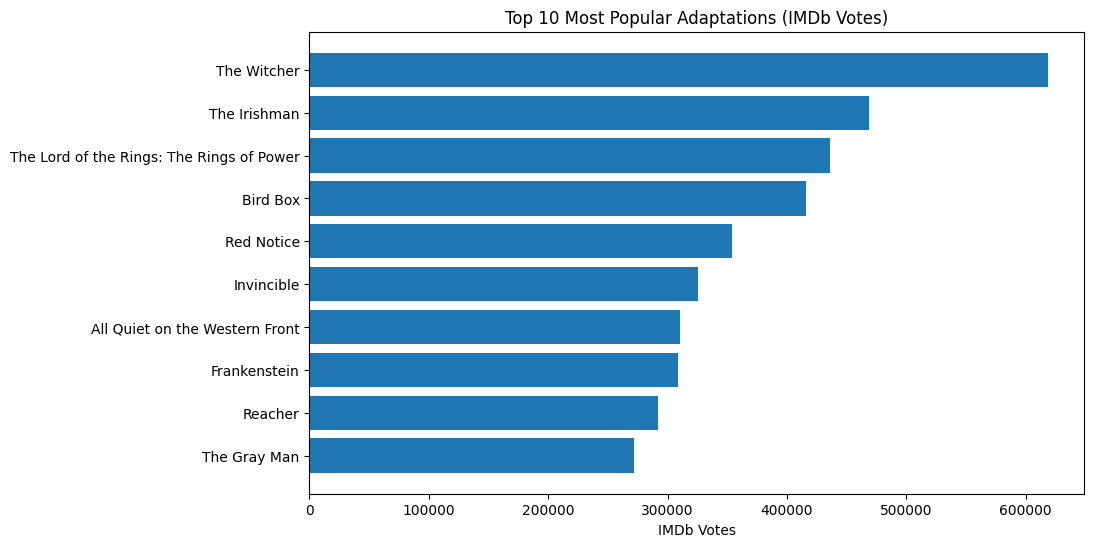

In [47]:
plt.figure(figsize=(10,6))

plt.barh(
    top_popular['Title'],
    top_popular['imdb_votes']
)

plt.title('Top 10 Most Popular Adaptations (IMDb Votes)')
plt.xlabel('IMDb Votes')
plt.gca().invert_yaxis()

plt.savefig('../visuals/top_popular_adaptations.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**

- Netflix dominates the list of the most popular adaptations, accounting for the majority of titles in the top 10.
- "The Witcher" is the most popular adaptation in the dataset, with over 618,000 IMDb votes.
- Large-scale fantasy and action adaptations such as "The Lord of the Rings: The Rings of Power" and "The Witcher" attract substantial audience engagement.
- Popular adaptations are predominantly recent high-budget productions released by major streaming platforms.

**Insight 17**

Netflix adaptations tend to attract greater audience engagement, as reflected by the higher number of IMDb votes among the most popular titles. High-budget fantasy and action adaptations appear particularly successful in attracting viewers.

In [48]:
top_series = (
    df[df['imdb_type'] == 'series']
    [['Title', 'platform', 'imdb_rating']]
    .sort_values(by='imdb_rating', ascending=False)
    .head(10)
)

top_series

,Title,platform,imdb_rating
12,Invincible,Amazon,8.7
77,One Piece,Netflix,8.3
91,One Hundred Years of Solitude,Netflix,8.3
11,Off Campus,Amazon,8.2
73,Dept. Q,Netflix,8.1
0,Reacher,Amazon,8.0
87,Black Warrant,Netflix,7.9
63,The Witcher,Netflix,7.9
2,The Terminal List,Amazon,7.9
66,The Lincoln Lawyer,Netflix,7.8


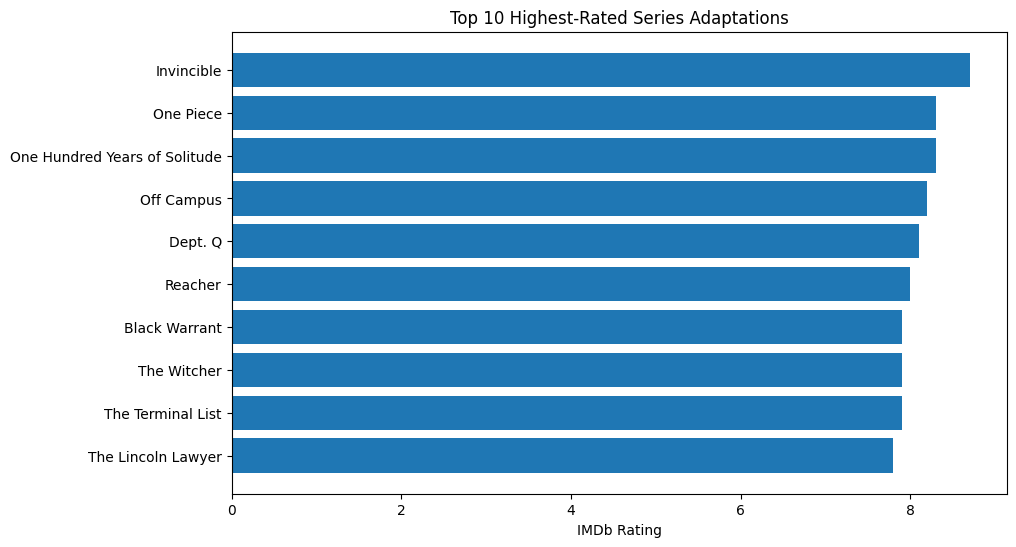

In [49]:
plt.figure(figsize=(10,6))

plt.barh(
    top_series['Title'],
    top_series['imdb_rating']
)

plt.title('Top 10 Highest-Rated Series Adaptations')
plt.xlabel('IMDb Rating')
plt.gca().invert_yaxis()

plt.show()

**Observations:**

- The highest-rated series adaptation in the dataset is "Invincible" (Amazon), with an IMDb rating of 8.7.
- Netflix dominates the list, contributing 6 out of the top 10 highest-rated series adaptations.
- Both Amazon and Netflix feature multiple critically acclaimed series, indicating that both platforms are capable of producing successful long-form adaptations.
- The top-rated series span diverse genres, including fantasy, action, historical drama, and crime, suggesting that high-quality adaptations are not limited to a single genre.
- Several highly rated series, such as "The Witcher", "Reacher", and "One Piece", are adaptations of well-established literary works or franchises.

**Insight 18**

High-quality book adaptations are strongly represented in the series format, with both Amazon and Netflix producing critically acclaimed titles. The presence of multiple highly rated fantasy, action, and drama series further supports the earlier finding that the episodic format is particularly well-suited for adapting complex literary works.

**Insight 19**

The dominance of highly rated series adaptations reinforces the earlier observation that series generally outperform movies in terms of audience ratings, possibly because the episodic format allows for more detailed storytelling and character development.

## Key Findings

1. Although Netflix adaptations substantially outnumber Amazon adaptations in the dataset, this difference primarily reflects the availability of source data rather than the actual number of adaptations produced by each platform.

2. Most adaptations receive moderate IMDb ratings, with the majority of titles clustered between 6 and 7. Extremely low-rated and highly rated adaptations are relatively uncommon.

3. Most adaptations are based on highly rated books, with Goodreads ratings concentrated around 4.0. However, the relationship between Goodreads ratings and adaptation ratings is only moderate (r = 0.37), indicating that highly rated books do not always result in highly rated adaptations.

4. Drama is the dominant genre across both platforms. Historical and biographical adaptations tend to receive the highest IMDb ratings, whereas Horror adaptations generally perform less favorably.

5. Series adaptations consistently outperform movie adaptations, receiving higher and more stable IMDb ratings. This suggests that the episodic format may be better suited for adapting complex literary works.

6. Amazon and Netflix exhibit remarkably similar adaptation quality and source material quality, as reflected by their nearly identical IMDb and Goodreads rating distributions.

7. Popularity and audience ratings show a moderate positive relationship, suggesting that widely viewed adaptations tend to receive more favorable audience reception, although popularity alone does not guarantee success.


## Limitations

* The dataset contains substantially more Netflix adaptations than Amazon adaptations because Netflix data was collected from multiple Wikipedia pages spanning 2015–2026, whereas Amazon data was obtained from a single Wikipedia source. Consequently, platform comparisons should be interpreted with caution.

* The dataset includes a larger number of movies than series, which may influence comparisons between adaptation formats.

* Data collection relied primarily on publicly available Wikipedia pages. As a result, some adaptations may be missing due to inconsistencies or omissions in the source pages.

* Goodreads and IMDb ratings are user-generated and may reflect subjective preferences, demographic biases, and temporal effects.

* Certain years, genres, and genre combinations contain relatively few observations, limiting the generalizability of conclusions drawn from those categories.

* Correlation analyses identify associations between variables but do not establish causal relationships.


## Conclusion

This study compared book-to-screen adaptations available on Amazon Prime Video and Netflix by integrating streaming platform metadata, IMDb ratings, and Goodreads ratings. The analysis revealed that both platforms exhibit broadly comparable adaptation quality and tend to adapt books that have already received positive reader reception. While book ratings demonstrate a moderate relationship with adaptation ratings, source material quality alone does not guarantee adaptation success.

Genre and format emerged as important factors influencing audience reception. Drama-oriented adaptations dominate both platforms, while historical and biographical adaptations generally achieve higher ratings. Additionally, series adaptations consistently outperform movies, suggesting that the episodic format may provide greater flexibility for adapting complex literary narratives. Overall, the findings indicate that successful adaptations depend on a combination of factors, including source material, genre, adaptation format, and audience engagement, rather than any single characteristic.
